# Guest experience — charts for Q1–Q4

This notebook loads CSV outputs in this folder and builds **one chart per question**, supporting [`04_guest_experience.txt`](04_guest_experience.txt).

**Run from project root** (`Airbnb/`) so the first cell finds `mba706_toolkit.py`. If your kernel cwd is elsewhere, change `ROOT` in that cell.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "mba706_toolkit.py").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(
        "Project root not found. Open the notebook from the Airbnb repo and set cwd to project root."
    )


ROOT = find_project_root()
BASE = ROOT / "results" / "04_guest_experience"
FIG_GUEST = ROOT / "reports" / "figures" / "04_guest_experience"
FIG_GUEST.mkdir(parents=True, exist_ok=True)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
%matplotlib inline

## Q1 — Complaint-oriented language in reviews, by city

**Idea:** Share of reviews with at least one problem-oriented cue (noise, smell, delays, etc.), by market. Source: `q1_review_complaints/q1_complaint_cue_rate_by_city.csv`.

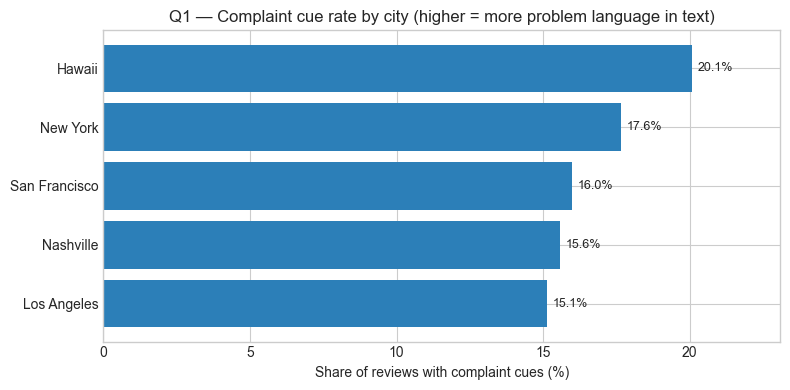

In [2]:
q1 = pd.read_csv(BASE / "q1_review_complaints" / "q1_complaint_cue_rate_by_city.csv")
q1 = q1.sort_values("share_complaint_cue", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(q1["City"], q1["share_complaint_cue"] * 100, color="#2c7fb8")
ax.set_xlabel("Share of reviews with complaint cues (%)")
ax.set_title("Q1 — Complaint cue rate by city (higher = more problem language in text)")
ax.set_xlim(0, max(q1["share_complaint_cue"] * 100) * 1.15)
for i, v in enumerate(q1["share_complaint_cue"] * 100):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_GUEST / "q1_complaint_cue_rate_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

## Q2 — Which sub-scores align with overall rating ≥ 4.9?

**Idea:** Random forest feature importance (and logistic coefficients) from the saved ranking. Source: `q2_five_star_drivers/q2_subscore_importance_ranking.csv`.

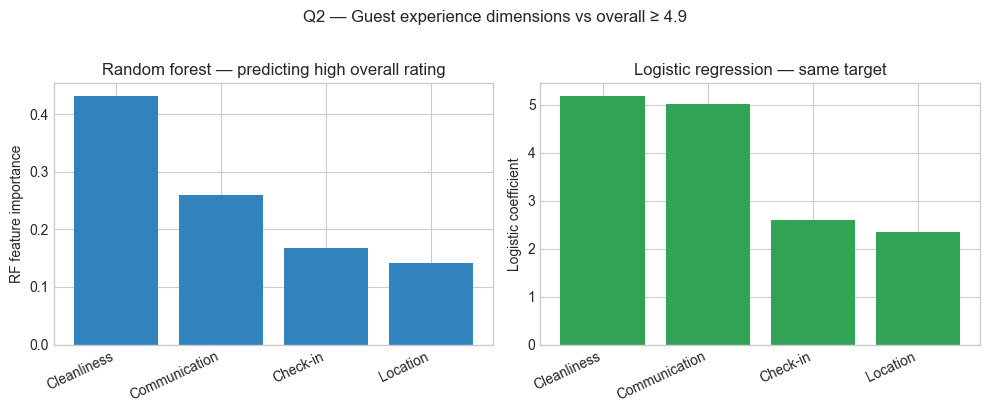

In [3]:
q2 = pd.read_csv(BASE / "q2_five_star_drivers" / "q2_subscore_importance_ranking.csv")
label_map = {
    "review_scores_cleanliness": "Cleanliness",
    "review_scores_checkin": "Check-in",
    "review_scores_communication": "Communication",
    "review_scores_location": "Location",
}
q2["dimension"] = q2["feature"].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = range(len(q2))
axes[0].bar(x, q2["rf_importance"], color="#3182bd")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(q2["dimension"], rotation=25, ha="right")
axes[0].set_ylabel("RF feature importance")
axes[0].set_title("Random forest — predicting high overall rating")

axes[1].bar(x, q2["logistic_coef"], color="#31a354")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(q2["dimension"], rotation=25, ha="right")
axes[1].set_ylabel("Logistic coefficient")
axes[1].set_title("Logistic regression — same target")

fig.suptitle("Q2 — Guest experience dimensions vs overall ≥ 4.9", y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(FIG_GUEST / "q2_subscore_drivers_rf_logistic.png", dpi=150, bbox_inches="tight")
plt.show()

## Q3 — Operational proxies (amenities) vs mean overall review score

**Idea:** For each flag, compare mean `review_scores_rating` when the flag is True vs False. Source: `q3_operational_investments/q3_operational_signal_assoc.csv`.

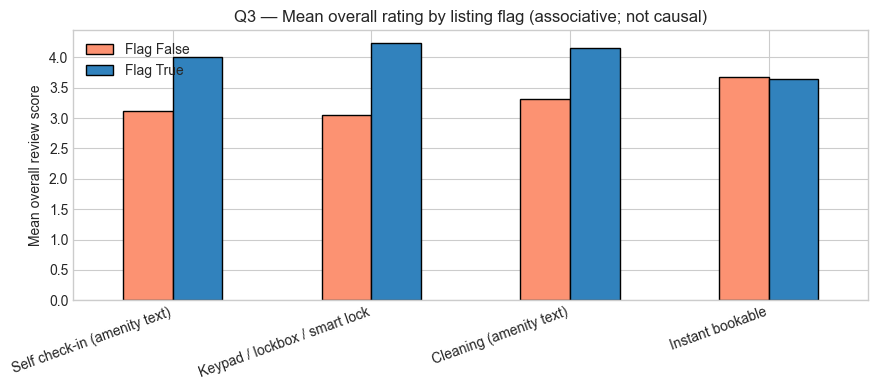

In [4]:
q3 = pd.read_csv(BASE / "q3_operational_investments" / "q3_operational_signal_assoc.csv")
signals = [
    "self_checkin_amenity",
    "keypad_lockbox",
    "cleaning_fee_listed",
    "instant_bookable_flag",
]
q3_sub = q3[q3["signal"].isin(signals)].copy()

pivot = q3_sub.pivot(index="signal", columns="flag", values="mean_overall_rating")
pivot = pivot.reindex(signals)
pivot.columns = ["Flag False", "Flag True"]

pretty = {
    "self_checkin_amenity": "Self check-in (amenity text)",
    "keypad_lockbox": "Keypad / lockbox / smart lock",
    "cleaning_fee_listed": "Cleaning (amenity text)",
    "instant_bookable_flag": "Instant bookable",
}
pivot.index = pivot.index.map(lambda s: pretty.get(s, s))

ax = pivot.plot(kind="bar", figsize=(9, 4), color=["#fc9272", "#3182bd"], edgecolor="black")
ax.set_ylabel("Mean overall review score")
ax.set_xlabel("")
ax.set_title("Q3 — Mean overall rating by listing flag (associative; not causal)")
ax.legend(title="")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Q4 — Terms that lift among top-quartile listings (TF–IDF deviations)

**Idea:** Top stems by lift (top quartile vs others) on listing–city deviation table. Source: `q4_top_performer_praise/q4_term_lift_top_vs_other.csv`.

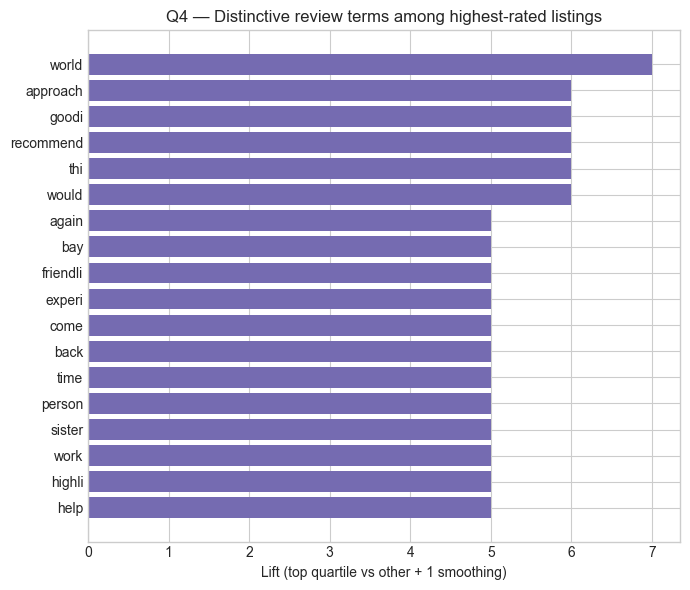

In [5]:
q4 = pd.read_csv(BASE / "q4_top_performer_praise" / "q4_term_lift_top_vs_other.csv")
top = q4.sort_values("lift_top_vs_other", ascending=False).head(18).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top["term"].astype(str), top["lift_top_vs_other"], color="#756bb1")
ax.set_xlabel("Lift (top quartile vs other + 1 smoothing)")
ax.set_title("Q4 — Distinctive review terms among highest-rated listings")
plt.tight_layout()
fig.savefig(FIG_GUEST / "q4_term_lift_top_performers.png", dpi=150, bbox_inches="tight")
plt.show()